<a href="https://colab.research.google.com/github/Harsh13964/project/blob/stock-price-prediction/stockpriceprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score

In [ ]:
bse = pd.read_excel('bse.xlsx')
bse.head()

,Date,Open,High,Low,Close
0,1995-11-03,3451.20,3470.26,3441.49,3469.40
1,1995-11-06,3472.70,3473.80,3418.43,3425.88
2,1995-11-08,3392.66,3426.05,3364.71,3364.71
3,1995-11-09,3339.33,3339.33,3316.00,3316.00
4,1995-11-10,3288.89,3288.89,3280.06,3287.12


In [ ]:
#make missing values null
bse_cleaned=bse.dropna()
print(bse_cleaned)

           Date      Open      High       Low     Close
0    1995-11-03   3451.20   3470.26   3441.49   3469.40
1    1995-11-06   3472.70   3473.80   3418.43   3425.88
2    1995-11-08   3392.66   3426.05   3364.71   3364.71
3    1995-11-09   3339.33   3339.33   3316.00   3316.00
4    1995-11-10   3288.89   3288.89   3280.06   3287.12
...         ...       ...       ...       ...       ...
6984 2024-01-08  72113.25  72181.77  71301.04  71355.22
6985 2024-01-09  71770.91  72035.47  71307.27  71386.21
6986 2024-01-10  71383.20  71733.84  71110.98  71657.71
6987 2024-01-11  71907.75  71999.47  71543.19  71721.18
6988 2024-01-12  72148.07  72720.96  71982.29  72568.45

[6989 rows x 5 columns]


In [ ]:
bse.describe()

,Date,Open,High,Low,Close
count,6989,6989.000000,6989.000000,6989.000000,6989.000000
mean,2009-12-14 13:15:18.414651648,20259.278529,20374.760229,20108.303606,20240.627745
min,1995-11-03 00:00:00,2621.890000,2682.590000,2594.870000,2600.120000
25%,2002-12-12 00:00:00,4623.830000,4667.020000,4574.170000,4616.010000
50%,2009-12-11 00:00:00,16860.160000,16987.060000,16692.660000,16852.910000
75%,2016-12-26 00:00:00,28690.660000,28829.290000,28483.990000,28661.580000
max,2024-01-12 00:00:00,72351.590000,72720.960000,72137.450000,72568.450000
std,NaN,17396.530947,17464.724701,17301.253275,17385.397495


In [ ]:
bse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6989 entries, 0 to 6988
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6989 non-null   datetime64[ns]
 1   Open    6989 non-null   float64       
 2   High    6989 non-null   float64       
 3   Low     6989 non-null   float64       
 4   Close   6989 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 273.1 KB


In [ ]:
# check null vaue
bse.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


In [ ]:
# unique values
bse.nunique()

,0
Date,6989
Open,6962
High,6975
Low,6973
Close,6977


In [ ]:
bse.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [ ]:
# Sort by date (optional but recommended)
bse['Date'] = pd.to_datetime(bse['Date'])
bse.sort_values('Date', inplace=True)

In [ ]:
# Create input features and target
bse['target'] = bse['Close'].shift(-1)  # next day's close as target

In [ ]:
# Drop the last row (target will be NaN)
bse.dropna(inplace=True)


In [ ]:
# Features and labels(retrain)
X = bse[['Open', 'High', 'Low', 'Close']]
y = bse['target']

In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Then test with same features
r2_score_stock_data = model.score(X_test, y_test)
print("R-squared:", r2_score_stock_data)

R-squared: 0.9980535189166916


In [ ]:
# Make predictions
predictions = model.predict(X_test)

In [ ]:
# split into features and target variable
X=bse.iloc[:,1:5]
Y=bse.iloc[:,5]

In [ ]:
print(Y)

0        3425.88
1        3364.71
2        3316.00
3        3287.12
4        3193.77
          ...   
6983    71355.22
6984    71386.21
6985    71657.71
6986    71721.18
6987    72568.45
Name: target, Length: 6988, dtype: float64


In [ ]:
# predict the model
y_pred = model.predict(X_test)

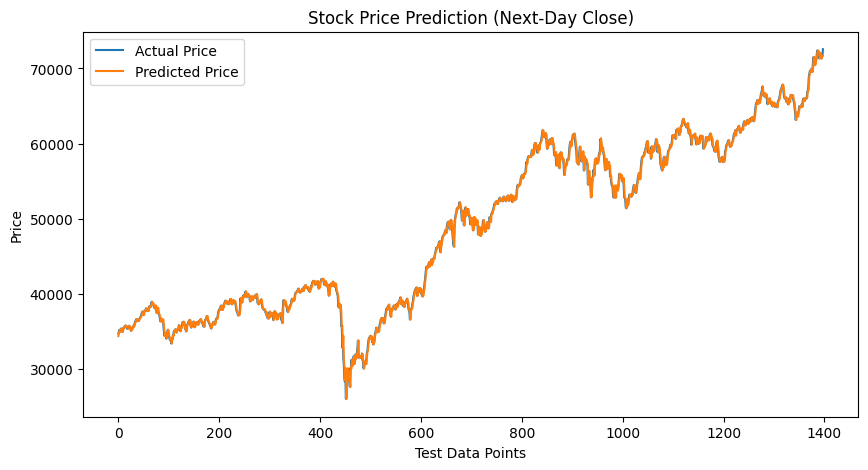

In [ ]:
# Plot actual vs predicted
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title("Stock Price Prediction (Next-Day Close)")
plt.xlabel("Test Data Points")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
# Predict future price (next day) using latest known data
latest_data = bse[['Open', 'High', 'Low', 'Close']].iloc[-1].values.reshape(1, -1)
future_price = model.predict(latest_data)
print(f"\nPredicted next day's closing price: ₹{future_price[0]:.2f}")


Predicted next day's closing price: ₹71721.52


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# save model using joblib
import joblib
joblib.dump(model, 'bse_model1.joblib')

['bse_model1.joblib']

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 253852.40
R-squared: 1.00


In [ ]:
# Example data
X = np.array([[6], [7], [8], [9], [10]])
y = np.array([2, 4, 6, 8, 10])  # target values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict(X)

# Calculate MSE
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

MSE: 0.0


In [ ]:
# Train the model on stock data again to ensure the correct model is used
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model using the R-squared score
r2_score_stock_data = model.score(X_test, y_test)
print("R-squared:", r2_score_stock_data)

R-squared: 0.9980535189166916


In [ ]:
# Compute correlation matrix
corr_matrix = bse.corr()

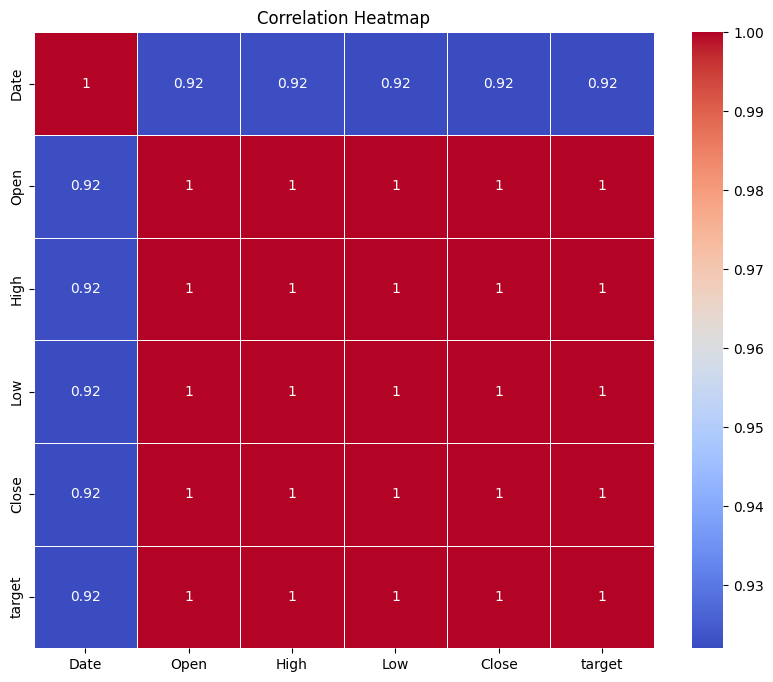

In [ ]:
# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

y_test shape: (1398,)
y_pred shape: (1398,)


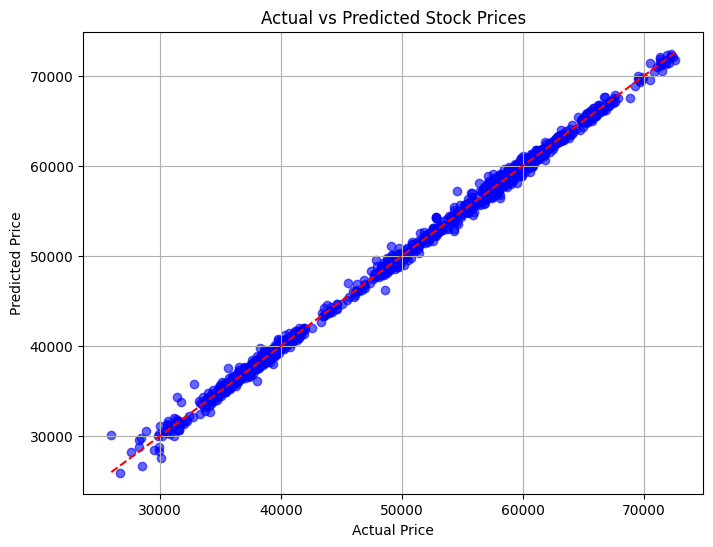

In [ ]:
# Ensure both arrays are 1D and same shape
# Use the y_test from the stock data analysis
# Calculate y_pred from the stock data's X_test right before plotting

# Retrain the model on the stock data to ensure the correct model is used
model = LinearRegression()
model.fit(X_train, y_train)

y_test_flat = np.ravel(y_test) # y_test from stock data split (size 1398)

# Make predictions using the trained model on X_test
y_pred = model.predict(X_test)
y_pred_flat = np.ravel(y_pred) # y_pred from stock data predictions on X_test (should be size 1398)


# Optional: print shapes to verify
print("y_test shape:", y_test_flat.shape)
print("y_pred shape:", y_pred_flat.shape)

# Now plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_flat, y_pred_flat, color='blue', alpha=0.6)
plt.plot([min(y_test_flat), max(y_test_flat)],
         [min(y_test_flat), max(y_test_flat)],
         color='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Stock Prices")
plt.grid(True)
plt.show()